In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def wrangler(data_path:str) -> pd.DataFrame:
    raw_data_file = Path(data_path).resolve()

    df = pd.read_csv(raw_data_file)

    # Fix column formatting
    df.columns = df.columns.str.lower().str.replace(" ", "_")

    # Fix string formatting
    col_str = tuple(df.dtypes[df.dtypes == "str"].index)
    for col in col_str:
        df[col] = df[col].str.lower().str.replace(" ", "_")

    return df

In [3]:
df = wrangler("./data.csv")
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               11914 non-null  str    
 1   model              11914 non-null  str    
 2   year               11914 non-null  int64  
 3   engine_fuel_type   11911 non-null  str    
 4   engine_hp          11845 non-null  float64
 5   engine_cylinders   11884 non-null  float64
 6   transmission_type  11914 non-null  str    
 7   driven_wheels      11914 non-null  str    
 8   number_of_doors    11908 non-null  float64
 9   market_category    8172 non-null   str    
 10  vehicle_size       11914 non-null  str    
 11  vehicle_style      11914 non-null  str    
 12  highway_mpg        11914 non-null  int64  
 13  city_mpg           11914 non-null  int64  
 14  popularity         11914 non-null  int64  
 15  msrp               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [5]:
df.nunique()

make                   48
model                 914
year                   28
engine_fuel_type       10
engine_hp             356
engine_cylinders        9
transmission_type       5
driven_wheels           4
number_of_doors         3
market_category        71
vehicle_size            3
vehicle_style          16
highway_mpg            59
city_mpg               69
popularity             48
msrp                 6049
dtype: int64

In [6]:
df.isna().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

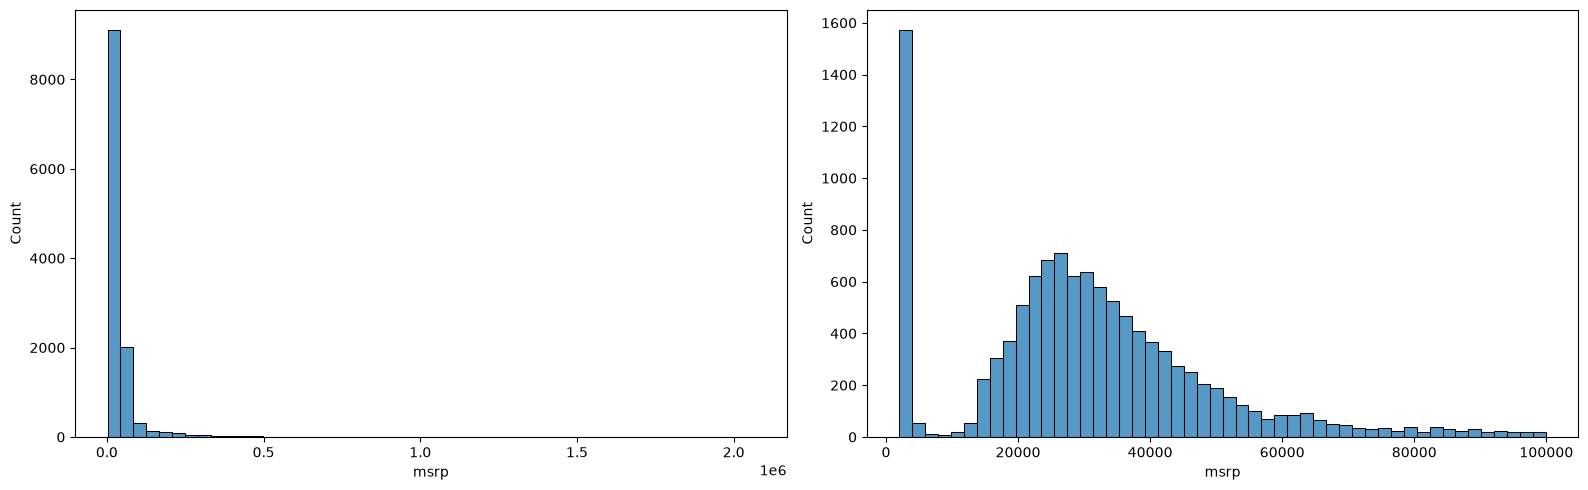

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(1600, 500, "px"))

sns.histplot(df["msrp"], bins=50, ax=ax[0])
sns.histplot(df["msrp"][df["msrp"] < 100_000], bins=50, ax=ax[1])

plt.tight_layout()

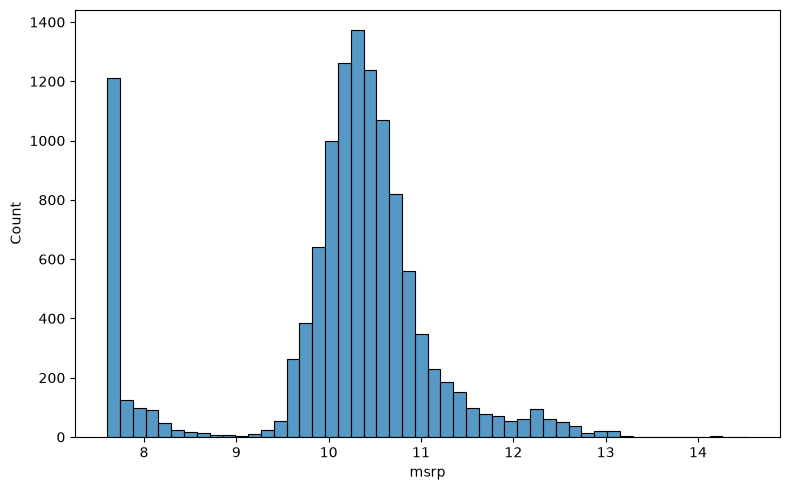

In [8]:
# Get natural logarithm of prices
price_logs = np.log1p(df["msrp"]) 

fig, ax = plt.subplots(figsize=(800, 500, "px"))
sns.histplot(price_logs, bins=50, ax=ax)
plt.tight_layout()

## Validation framework
- Split the data into train, validate, and test, then prepare target for each part
- Manual process with NumPy and Pandas
- Note that in `scikit-learn` this could be easily done using built-in methods/functions

In [9]:
# Calculate size of parts

nrows = len(df)

n_val = int(nrows * 0.2)
n_test = int(nrows * 0.2)
n_train = nrows - (n_val + n_test)

nrows, n_train, n_val, n_test

(11914, 7150, 2382, 2382)

In [10]:
# Divide dataframe into said parts

df_val = df.iloc[:n_val]
df_test = df.iloc[n_val:n_val+n_test]
df_train = df.iloc[n_val+n_test:]

len(df_val), len(df_test), len(df_train)

(2382, 2382, 7150)

In [11]:
# Divide dataframe into said parts properly (shuffle)

idx = np.arange(nrows)
np.random.seed(13)
np.random.shuffle(idx)

print(idx)

df_val = df.iloc[idx[:n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_val:n_val+n_test]].reset_index(drop=True)
df_train = df.iloc[idx[n_val+n_test:]].reset_index(drop=True)

len(df_val), len(df_test), len(df_train)

[ 8684  1322 11393 ...  7696    74   338]


(2382, 2382, 7150)

In [12]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,lexus,rx_400h,2007,regular_unleaded,268.0,6.0,automatic,front_wheel_drive,4.0,"crossover,luxury,hybrid",midsize,4dr_suv,25,28,454,41180
1,suzuki,aerio,2006,regular_unleaded,155.0,4.0,automatic,all_wheel_drive,4.0,NaN,compact,wagon,26,21,481,17099
2,dodge,viper,2017,premium_unleaded_(required),645.0,10.0,manual,rear_wheel_drive,2.0,"exotic,high-performance",compact,coupe,19,12,1851,107995
3,pontiac,6000,1990,regular_unleaded,110.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,29,20,210,2000
4,chevrolet,astro_cargo,2005,regular_unleaded,190.0,6.0,automatic,all_wheel_drive,3.0,NaN,large,cargo_minivan,18,14,1385,25430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,saab,9-3_griffin,2012,flex-fuel_(premium_unleaded_recommended/e85),220.0,4.0,automatic,front_wheel_drive,4.0,"flex_fuel,luxury",midsize,sedan,29,19,376,34340
2378,audi,q5,2017,flex-fuel_(premium_unleaded_recommended/e85),220.0,4.0,automatic,all_wheel_drive,4.0,"crossover,flex_fuel,luxury",midsize,4dr_suv,27,20,3105,43150
2379,acura,mdx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,all_wheel_drive,4.0,"crossover,luxury",midsize,4dr_suv,26,19,204,57230
2380,dodge,ram_pickup_1500,2009,regular_unleaded,390.0,8.0,automatic,four_wheel_drive,4.0,NaN,large,crew_cab_pickup,18,13,1851,41340


In [13]:
df_test

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,buick,reatta,1991,regular_unleaded,170.0,6.0,automatic,front_wheel_drive,2.0,luxury,compact,convertible,25,16,155,2000
1,kia,rio,2015,regular_unleaded,138.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,27,1720,18290
2,bentley,continental_gt,2016,premium_unleaded_(required),582.0,12.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,coupe,21,12,520,214600
3,volkswagen,tiguan,2016,premium_unleaded_(recommended),200.0,4.0,automatic,front_wheel_drive,4.0,crossover,compact,4dr_suv,26,21,873,34445
4,cadillac,ct6,2016,premium_unleaded_(required),404.0,6.0,automatic,all_wheel_drive,4.0,"luxury,high-performance",large,sedan,26,18,1624,67570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,subaru,impreza_wrx,2014,premium_unleaded_(required),305.0,4.0,manual,all_wheel_drive,4.0,"factory_tuner,high-performance",compact,sedan,23,17,640,34495
2378,subaru,brz,2015,premium_unleaded_(required),200.0,4.0,manual,rear_wheel_drive,2.0,performance,compact,coupe,30,22,640,29490
2379,cadillac,ct6,2016,regular_unleaded,335.0,6.0,automatic,all_wheel_drive,4.0,"luxury,performance",large,sedan,27,18,1624,63570
2380,volvo,s40,2009,premium_unleaded_(recommended),227.0,5.0,automatic,all_wheel_drive,4.0,luxury,compact,sedan,26,18,870,33800


In [14]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,trailblazer,2007,premium_unleaded_(required),395.0,8.0,automatic,rear_wheel_drive,4.0,"factory_tuner,performance",midsize,4dr_suv,17,13,1385,34885
1,toyota,tacoma,2016,regular_unleaded,278.0,6.0,automatic,rear_wheel_drive,4.0,NaN,compact,crew_cab_pickup,24,19,2031,28845
2,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,2.0,flex_fuel,large,regular_cab_pickup,22,17,1385,35135
3,nissan,frontier,2016,regular_unleaded,261.0,6.0,automatic,rear_wheel_drive,4.0,NaN,compact,crew_cab_pickup,22,16,2009,25840
4,dodge,ram_150,1991,regular_unleaded,170.0,8.0,manual,rear_wheel_drive,2.0,NaN,large,extended_cab_pickup,14,11,1851,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,saab,9-5,2011,premium_unleaded_(recommended),220.0,4.0,manual,front_wheel_drive,4.0,luxury,large,sedan,33,20,376,38525
7146,toyota,tundra,2016,flex-fuel_(unleaded/e85),381.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,17,13,2031,49580
7147,toyota,prius,2015,regular_unleaded,134.0,4.0,automatic,front_wheel_drive,4.0,"hatchback,hybrid",compact,4dr_hatchback,48,51,2031,23215
7148,chrysler,200,2016,flex-fuel_(unleaded/e85),184.0,4.0,automatic,front_wheel_drive,4.0,flex_fuel,midsize,sedan,36,23,1013,22490


In [15]:
# Preparing target and removing original values (to avoid accidental usage in training)

y_train = np.log1p(df_train["msrp"].values)
y_val = np.log1p(df_val["msrp"].values)
y_test = np.log1p(df_test["msrp"].values)

df_train.drop("msrp", axis=1, inplace=True)
df_val.drop("msrp", axis=1, inplace=True)
df_test.drop("msrp", axis=1, inplace=True)

df_train.shape, df_val.shape, df_test.shape

((7150, 15), (2382, 15), (2382, 15))

## Define Linear Regression

In [16]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

## Baseline Model

In [17]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [18]:
base = [
    "engine_hp",
    "engine_cylinders",
    "highway_mpg",
    "city_mpg",
    "popularity"
]

In [19]:
X_train = df_train[base].fillna(0).values
X_train

array([[ 395.,    8.,   17.,   13., 1385.],
       [ 278.,    6.,   24.,   19., 2031.],
       [ 285.,    6.,   22.,   17., 1385.],
       ...,
       [ 134.,    4.,   48.,   51., 2031.],
       [ 184.,    4.,   36.,   23., 1013.],
       [ 332.,    6.,   26.,   19., 2009.]], shape=(7150, 5))

In [20]:
w0, w = train_linear_regression(X_train, y_train)

In [21]:
w0

np.float64(7.497007053204125)

In [22]:
w

array([ 9.31666788e-03, -1.17546545e-01,  4.26232025e-02, -7.05368634e-03,
       -1.42892366e-05])

In [23]:
y_pred = w0 + X_train.dot(w)
y_pred

array([10.84982443, 10.24167683, 10.24498532, ...,  9.93240865,
       10.09881327, 10.83033767], shape=(7150,))

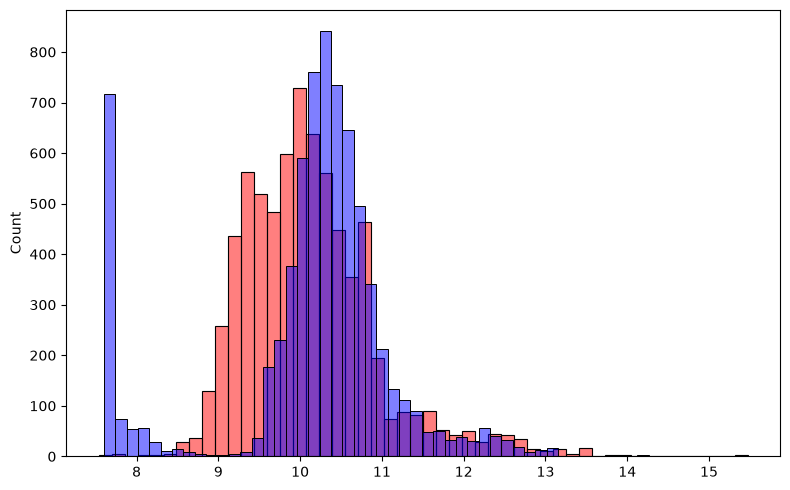

In [25]:
fig, ax = plt.subplots(figsize=(800, 500, "px"))
sns.histplot(y_pred, color='red', alpha=0.5, bins=50, ax=ax)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50, ax=ax)
plt.tight_layout()

In [26]:
# Check RSME to assess model performance

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [28]:
# RSME of the baseline model (based on training data)

rmse(y_train, y_pred)

np.float64(0.7437651810978518)

## Model Validation

In [29]:
def prepare_X(df: pd.Dataframe) -> pd.DataFrame:
    """Prepare feature matrix for training."""
    
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [30]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.7889451062518066)

## Feature engineering

In [31]:
def prepare_X(df):
    df = df.copy()

    df['age'] = 2017 - df.year
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [32]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5215203983071113)

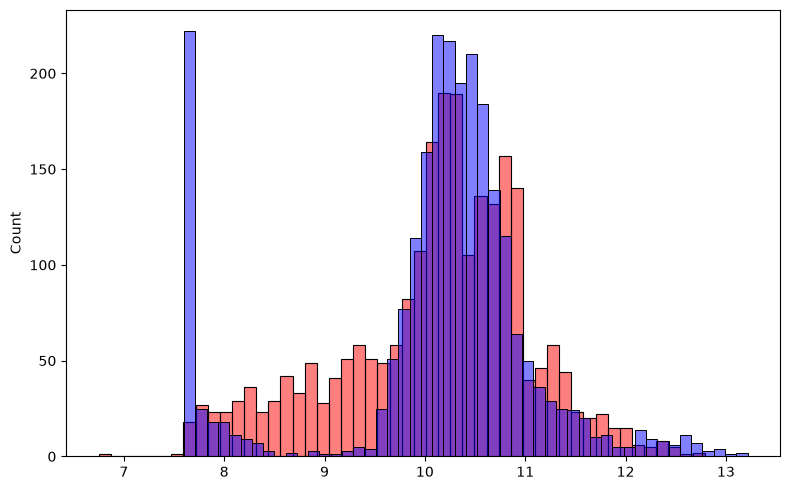

In [36]:
fig, ax = plt.subplots(figsize=(800, 500, "px"))
sns.histplot(y_pred, color='red', alpha=0.5, bins=50, ax=ax)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50, ax=ax)
plt.tight_layout()

## Categorical variables

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               11914 non-null  str    
 1   model              11914 non-null  str    
 2   year               11914 non-null  int64  
 3   engine_fuel_type   11911 non-null  str    
 4   engine_hp          11845 non-null  float64
 5   engine_cylinders   11884 non-null  float64
 6   transmission_type  11914 non-null  str    
 7   driven_wheels      11914 non-null  str    
 8   number_of_doors    11908 non-null  float64
 9   market_category    8172 non-null   str    
 10  vehicle_size       11914 non-null  str    
 11  vehicle_style      11914 non-null  str    
 12  highway_mpg        11914 non-null  int64  
 13  city_mpg           11914 non-null  int64  
 14  popularity         11914 non-null  int64  
 15  msrp               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [44]:
df.select_dtypes("str").columns

Index(['make', 'model', 'engine_fuel_type', 'transmission_type',
       'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style'],
      dtype='str')

In [46]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    # Encoding categories as binary columns (1s and 0s)
    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [47]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5231316439865437)

In [50]:
df["make"].value_counts().head(10)

make
chevrolet     1123
ford           881
volkswagen     809
toyota         746
dodge          626
nissan         558
gmc            515
honda          449
mazda          423
cadillac       397
Name: count, dtype: int64

In [52]:
# Most popular makes
makes = list(df["make"].value_counts().head().index)
makes

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [53]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    # Encoding categories as binary columns (1s and 0s) for number of doors
    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    # Encoding categories for makes
    for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [54]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5299801061600256)

In [56]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    categorical_variables = [
        'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
        'market_category', 'vehicle_size', 'vehicle_style'
    ]
    
    categories = {}
    
    for c in categorical_variables:
        categories[c] = list(df_train[c].value_counts().head().index)

    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [57]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(569.1341055926987)

## Regularization (Ridge method)

In [58]:
def train_linear_regression(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [59]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5073533554935328)

## Finetuning

In [63]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred).round(4)

    print(r, w0, score)

0.0 1.6641291986456052e+16 569.1341
1e-05 8.83846070947502 0.5074
0.0001 6.20648527524215 0.5074
0.001 6.222294788737383 0.5074
0.1 6.199455609268815 0.506
1 6.00413667526397 0.4954
10 4.7968225182580975 0.4777


In [69]:
# Final training
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train, r=0.001)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5073533554935328)

## Final testing

In [107]:
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,trailblazer,2007,premium_unleaded_(required),395.0,8.0,automatic,rear_wheel_drive,4.0,"factory_tuner,performance",midsize,4dr_suv,17,13,1385
1,toyota,tacoma,2016,regular_unleaded,278.0,6.0,automatic,rear_wheel_drive,4.0,NaN,compact,crew_cab_pickup,24,19,2031
2,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,2.0,flex_fuel,large,regular_cab_pickup,22,17,1385
3,nissan,frontier,2016,regular_unleaded,261.0,6.0,automatic,rear_wheel_drive,4.0,NaN,compact,crew_cab_pickup,22,16,2009
4,dodge,ram_150,1991,regular_unleaded,170.0,8.0,manual,rear_wheel_drive,2.0,NaN,large,extended_cab_pickup,14,11,1851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,saab,9-3_griffin,2012,flex-fuel_(premium_unleaded_recommended/e85),220.0,4.0,automatic,front_wheel_drive,4.0,"flex_fuel,luxury",midsize,sedan,29,19,376
9528,audi,q5,2017,flex-fuel_(premium_unleaded_recommended/e85),220.0,4.0,automatic,all_wheel_drive,4.0,"crossover,flex_fuel,luxury",midsize,4dr_suv,27,20,3105
9529,acura,mdx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,all_wheel_drive,4.0,"crossover,luxury",midsize,4dr_suv,26,19,204
9530,dodge,ram_pickup_1500,2009,regular_unleaded,390.0,8.0,automatic,four_wheel_drive,4.0,NaN,large,crew_cab_pickup,18,13,1851


In [108]:
y_full_train = np.concatenate([y_train, y_val])
y_full_train

array([10.45984088, 10.26972661, 10.46698152, ..., 10.95485099,
       10.62961002, 10.45722898], shape=(9532,))

In [109]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    print(se)
    
    mse = se.mean()
    print(mse)
    
    return np.sqrt(mse)

In [110]:
X_full_train = prepare_X(df_full_train)
w0, w = train_linear_regression(X_full_train, y_full_train, r=0.001)

X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)

[0.78244472 0.03278682 0.10752861 ... 0.10157487 0.14513153 0.00149622]
0.2082844125507492


In [111]:
score

np.float64(0.45638187140896513)

In [119]:
np.expm1(score)

np.float64(0.5783529575666055)

In [112]:
testcar = df_test.iloc[13].to_dict()
testcar

{'make': 'ferrari',
 'model': 'f12_berlinetta',
 'year': 2014,
 'engine_fuel_type': 'premium_unleaded_(required)',
 'engine_hp': 731.0,
 'engine_cylinders': 12.0,
 'transmission_type': 'automated_manual',
 'driven_wheels': 'rear_wheel_drive',
 'number_of_doors': 2.0,
 'market_category': 'exotic,high-performance',
 'vehicle_size': 'midsize',
 'vehicle_style': 'coupe',
 'highway_mpg': 16,
 'city_mpg': 11,
 'popularity': 2774}

In [113]:
df_small = pd.DataFrame([testcar])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,ferrari,f12_berlinetta,2014,premium_unleaded_(required),731.0,12.0,automated_manual,rear_wheel_drive,2.0,"exotic,high-performance",midsize,coupe,16,11,2774


In [114]:
X_small = prepare_X(df_small)
X_small

array([[7.310e+02, 1.200e+01, 1.600e+01, 1.100e+01, 2.774e+03, 3.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00]])

In [115]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(12.516321631519002)

In [116]:
np.expm1(y_pred).round(2)

np.float64(272751.93)

In [118]:
np.expm1(y_test[13]).round(2)

np.float64(315888.0)